# Emulating the Variance Reduction Test from pyMC3

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

from scipy.integrate import solve_ivp

import tinyDA as tda

In [47]:
np.random.seed(987)

In [48]:
class LinearModel:
    def __init__(self, x):
        self.x = x
    def __call__(self, parameters):
        out = parameters[0] + parameters[1] * self.x
        return out, out.mean()          # (model output, QoI) — same pattern as your PredatorPreyModel

In [49]:
x = np.linspace(0, 1, 100)
y = 1 + 2*x + np.random.normal(0, 0.2**2, 100)   # note: their notebook uses sigma**2 as the std — a quirk, but reproduce it if you want their numbers

models = [LinearModel(x[::3]), LinearModel(x[::2]), LinearModel(x)]
datasets = [y[::3], y[::2], y]

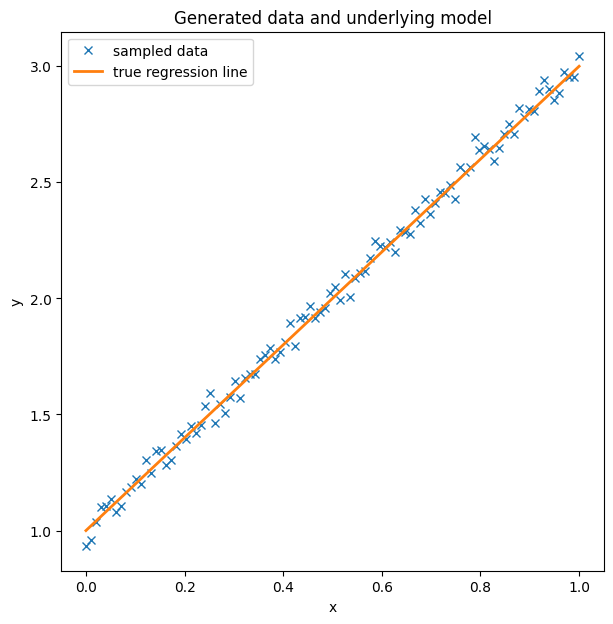

In [50]:
# Plot the data
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel="x", ylabel="y", title="Generated data and underlying model")
ax.plot(x, y, "x", label="sampled data")
ax.plot(x, 1 + 2*x , label="true regression line", lw=2.0)
plt.legend(loc=0);

In [51]:
prior = stats.multivariate_normal(np.zeros(2), 400*np.eye(2))   # their Normal(0, sigma=20) priors

In [52]:
posteriors = [tda.Posterior(prior, tda.GaussianLogLike(d, 0.2**2*np.eye(d.size)), m)
              for m, d in zip(models, datasets)]

In [70]:
# random walk Metropolis
#rwmh_cov = np.eye(2)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Nicolson
pcn_scaling = 0.1
pcn_adaptive = True
my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# adaptive Metropolis
#am_cov = np.eye(2)
#am_t0 = 2000
#am_sd = 1
#am_epsilon = 1e-6
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

In [71]:
chain = tda.sample(posteriors, my_proposal, iterations=6000, n_chains=1,
                   subchain_length=5, randomize_subchain_length=True)

Sampling chain 1/1


Running chain, α = 1.00:   0%|          | 0/6000 [00:00<?, ?it/s]/Users/louisekluge/tinyDA/tinyDA/proposal.py:362: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.likelihood - previous_link.likelihood)
/Users/louisekluge/tinyDA/tinyDA/proposal.py:1658: RuntimeWarning: overflow encountered in exp
  return np.exp(
Running chain, α = 0.76: 100%|██████████| 6000/6000 [01:57<00:00, 51.28it/s] 


In [55]:
mlinf = tda.get_multilevel_inference_data(chain, attribute='qoi', burnin=1000)

np.savez('qoi_linear.npz',
         **{k: np.asarray(v) for k, v in mlinf['chains'].items()},
         **{f'prom_{k}': np.asarray(v) for k, v in mlinf['promoted'].items()})

In [56]:
print(mlinf['levels'], mlinf['n_chains'])
print({k: v.shape if hasattr(v, 'shape') else len(v) for k, v in mlinf['chains'].items()})

3 1
{'level0_chain0': (125000, 1), 'level1_chain0': (25000, 1), 'level2_chain0': (5000, 1)}


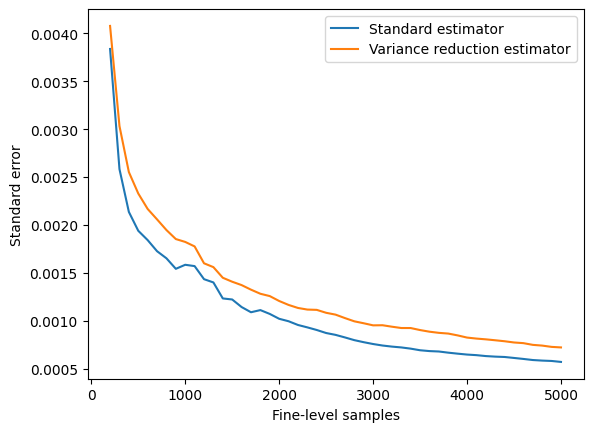

In [57]:
d = np.load('qoi_linear.npz')   # your linear-run output file

Q0  = d['level0_chain0']
Q2  = d['level2_chain0']
Y10 = d['level1_chain0'] - d['prom_level0_chain0']
Y21 = d['level2_chain0'] - d['prom_level1_chain0']

# sanity: paired arrays must align elementwise
assert len(d['level1_chain0']) == len(d['prom_level0_chain0'])
assert len(d['level2_chain0']) == len(d['prom_level1_chain0'])

# level growth ratios, measured not assumed (~nsub and ~nsub²)
r1 = len(d['level1_chain0']) / len(Q2)
r0 = len(Q0) / len(Q2)

def se(x):
    x = np.asarray(x, dtype=np.float64)
    return x.var() / az.ess(az.convert_to_dataset(x[None, :]))["x"].item()

N    = len(Q2)
step = 100
idx  = np.arange(200, N + 1, step)      # start at 200: ESS on tiny prefixes is junk

STD_SE = np.array([np.sqrt(se(Q2[:i])) for i in idx])
VR_SE  = np.array([np.sqrt(se(Q0[:int(i * r0)])
                         + se(Y10[:int(i * r1)])
                         + se(Y21[:i])) for i in idx])

plt.plot(idx, STD_SE, label="Standard estimator")
plt.plot(idx, VR_SE,  label="Variance reduction estimator")
plt.xlabel("Fine-level samples"); plt.ylabel("Standard error"); plt.legend()
plt.show()

In [58]:
print("Q0 mean :", Q0.mean())
print("Y10 mean:", Y10.mean(), "  Y21 mean:", Y21.mean())
print("VR estimate :", Q0.mean() + Y10.mean() + Y21.mean())
print("STD estimate:", Q2.mean())
print("variances — Q2:", Q2.var(), " Q0:", Q0.var(),
      " Y10:", Y10.var(), " Y21:", Y21.var())

Q0 mean : 2.0095628395495764
Y10 mean: -0.013917670041677795   Y21 mean: 0.011296415624632353
VR estimate : 2.0069415851325307
STD estimate: 2.0068662876044683
variances — Q2: 0.0003813233331513132  Q0: 0.0007441045852187782  Y10: 0.00030431780960547773  Y21: 0.0002730569741982895


In [59]:
se(Q2)

3.2651900105194675e-07

In [60]:
se(Q0)

1.6288353931196648e-07

In [61]:
se(Y10)

1.8606912296318998e-07

In [62]:
se(Y21)

1.7328161761131598e-07

In [63]:
c2 = np.ravel(np.asarray(d['level2_chain0'], float))
p1 = np.ravel(np.asarray(d['prom_level1_chain0'], float))
print(c2.shape, p1.shape, np.isnan(c2).sum(), np.isnan(p1).sum())
print(np.corrcoef(c2, p1)[0, 1])

(5000,) (5000,) 0 0
0.7250423776043304


fraction of near-constant pairs: 0.8586


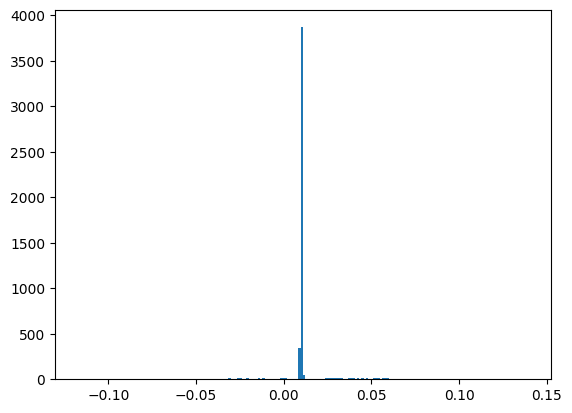

In [64]:
plt.hist(Y21, bins=200)
print("fraction of near-constant pairs:", np.mean(np.abs(Y21 - Y21.mean()) < 0.005))

In [65]:
moved = np.r_[True, np.diff(c2) != 0]          # fine chain accepted at step i?
p1_state = p1.copy()
for i in range(1, len(p1_state)):
    if not moved[i]:
        p1_state[i] = p1_state[i - 1]

Y21_state = c2 - p1_state
print("proposal-paired:  mean", Y21.mean(),       " var", Y21.var())
print("state-paired:  mean", Y21_state.mean(), " var", Y21_state.var())

proposal-paired:  mean 0.011296415624632353  var 0.0002730569741982895
state-paired:  mean 0.010168073270398797  var 1.1640497627552192e-07


In [66]:
c1 = np.ravel(np.asarray(d['level1_chain0'], float))
p0 = np.ravel(np.asarray(d['prom_level0_chain0'], float))
print(c1.shape, p0.shape, np.isnan(c1).sum(), np.isnan(p0).sum())
print(np.corrcoef(c1, p0)[0, 1])

(25000,) (25000,) 0 0
0.7726363026849509


In [67]:
moved = np.r_[True, np.diff(c1) != 0]          # fine chain accepted at step i?
p0_state = p0.copy()
for i in range(1, len(p0_state)):
    if not moved[i]:
        p0_state[i] = p0_state[i - 1]

Y10_state = c1 - p0_state
print("proposal-paired:  mean", Y10.mean(),       " var", Y10.var())
print("state-paired:     mean", Y10_state.mean(), " var", Y10_state.var())

proposal-paired:  mean -0.013917670041677795  var 0.00030431780960547773
state-paired:     mean -0.011410691588282243  var 0.00013275284933966469


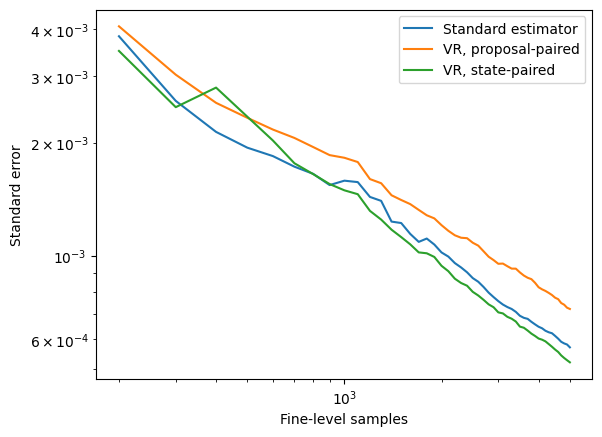

In [68]:
def state_pair(fine, promoted):
    """Hold the previous promoted value whenever the fine chain didn't move."""
    fine = np.ravel(np.asarray(fine, float))
    prom = np.ravel(np.asarray(promoted, float)).copy()
    moved = np.r_[True, np.diff(fine) != 0]
    for i in range(1, len(prom)):
        if not moved[i]:
            prom[i] = prom[i - 1]
    return fine - prom

Y21_s = state_pair(d['level2_chain0'], d['prom_level1_chain0'])
Y10_s = state_pair(d['level1_chain0'], d['prom_level0_chain0'])

VR_SE_state = np.array([np.sqrt(se(Q0[:int(i * r0)])
                              + se(Y10_s[:int(i * r1)])
                              + se(Y21_s[:i])) for i in idx])

plt.loglog(idx, STD_SE,      label="Standard estimator")
plt.loglog(idx, VR_SE,       label="VR, proposal-paired")
plt.loglog(idx, VR_SE_state, label="VR, state-paired")
plt.xlabel("Fine-level samples"); plt.ylabel("Standard error")
plt.legend(); plt.show()

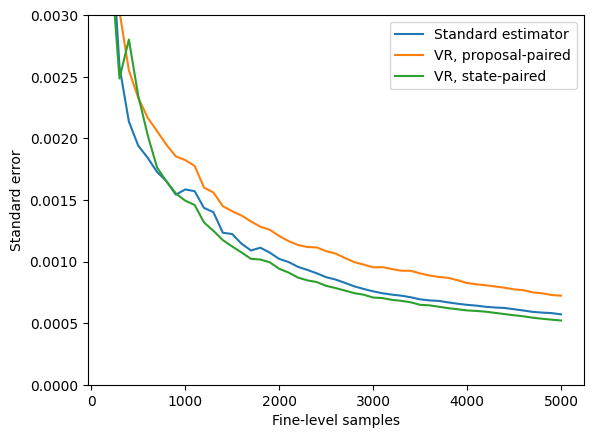

In [69]:
plt.plot(idx, STD_SE,      label="Standard estimator")
plt.plot(idx, VR_SE,       label="VR, proposal-paired")
plt.plot(idx, VR_SE_state, label="VR, state-paired")
#plt.axhline(2.3e-3, ls=':', color='grey', label="state-paired bias")
plt.ylim(0, 0.003)
plt.xlabel("Fine-level samples"); plt.ylabel("Standard error")
plt.legend(); plt.show()